In [1]:
import numpy as np
import pandas as pd
import duckdb
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
print(f"I am currently in: {os.getcwd()}")
print(f"Files I can see here: {os.listdir('.')}")

I am currently in: C:\dev\AAV_Process_Modeling\notebooks
Files I can see here: ['.ipynb_checkpoints', '2026_05_04_cleaning_EDA.ipynb', '2026_05_04_generate_data.ipynb', '2026_05_04_monitoring_engine.ipynb', 'aav_manufacturing.db']


While this pipeline uses Pandas for 50 batches, for industrial scale (10,000+ batches), 
I would implement a Partitioned Processing strategy or SQL-side Window Functions 
to minimize memory overhead and ensure the analysis process remains performant.

In [3]:
# Get the path of the folder holding this notebook, then go up one
project_root = os.path.dirname(os.getcwd())

# Connect to a database file (this creates it if it doesn't exist)
con = duckdb.connect('../aav_manufacturing.db') 

# Create or replace the Telemetry and outcomes tables directly from the CSV
con.execute(f"CREATE OR REPLACE TABLE telemetry AS SELECT * FROM '{os.path.join(project_root, 'data', 'raw', 'telemetry_batches.csv')}'")
con.execute(f"CREATE OR REPLACE TABLE outcomes AS SELECT * FROM '{os.path.join(project_root, 'data', 'raw', 'batch_outcomes.csv')}'")

# Creates an index to make the query faster
con.execute("CREATE INDEX IF NOT EXISTS idx_batch_id ON telemetry (Batch_ID);")

print(con.execute("SHOW TABLES").fetchall())


[('outcomes',), ('telemetry',), ('telemetry_aligned',)]


## Code for alignement of telemetry data

In [4]:
query = """
    SELECT 
    Hour,
    Batch_ID, 
    VCD, 
    Glucose, 
    Lactate, 
    Ammonia, 
    Product,
    pH,
    FROM telemetry 
    """

df_messy = con.execute(query).df()

# Define a clean 1-hour grid
clean_grid = np.arange(0, 241, 1)

# We isolate the numeric columns so 'Batch_ID' doesn't cause a warning
cols_to_sync = ['VCD', 'Glucose', 'Lactate', 'Ammonia', 'Product', 'pH']

def align_telemetry(group):
    # 1. Combine existing hours with the target grid
    target_indices = pd.Index(clean_grid, name='Hour')
    combined_indices = group.set_index('Hour').index.union(target_indices)
    
    # 2. Reindex to the combined set (preserves all original data points)
    return (group.set_index('Hour')[cols_to_sync]
                 .reindex(combined_indices)
                 .sort_index()
                 .interpolate(method='linear') # Interpolates using the float distances
                 .ffill()
                 .bfill()
                 .loc[clean_grid]) # Finally, keep only the exact hours from your grid

df_cleaned = (
    df_messy
    .groupby('Batch_ID')
    .apply(align_telemetry, include_groups=False)
    .reset_index()
)

con.execute(f"CREATE OR REPLACE TABLE telemetry_aligned AS SELECT * FROM df_cleaned")

## Selecting the highest performing batches

In [5]:
# Query the top 5 batches by Titer
query = """
    SELECT Batch_ID, Total_Titer, Full_Titer, Percent_Full
    FROM outcomes 
    ORDER BY Full_Titer DESC 
    LIMIT 5
    """

df_top = con.execute(query).df()
print("Top Performing Batches:")
display(df_top)



Top Performing Batches:


,Batch_ID,Total_Titer,Full_Titer,Percent_Full
0,BATCH_014,7.137108,2.816170,39.458135
1,BATCH_041,7.137108,2.683434,37.598344
2,BATCH_024,7.137108,2.665729,37.350264
3,BATCH_015,7.137108,2.635073,36.920734
4,BATCH_031,7.137108,2.633645,36.900730


In [6]:
## Comparing pH profile of the different cultures

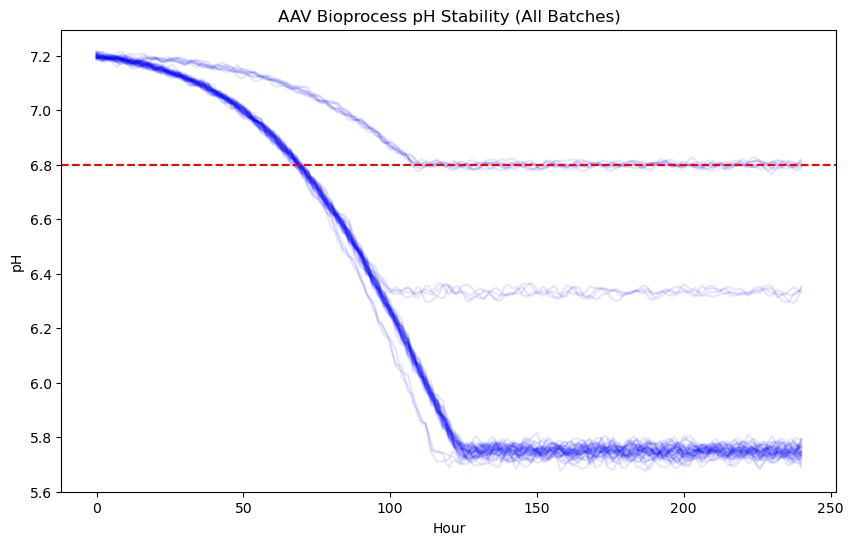

In [7]:
import matplotlib.pyplot as plt

# Pull pH data for all batches
df_ph = con.execute("SELECT Hour, pH, Batch_ID FROM telemetry_aligned").df()

plt.figure(figsize=(10, 6))
# We group by Batch_ID to plot a line for each individual run
for label, df in df_ph.groupby('Batch_ID'):
    plt.plot(df['Hour'], df['pH'], color='blue', alpha=0.1) # alpha makes lines semi-transparent

plt.axhline(y=6.8, color='red', linestyle='--', label='Critical pH Threshold')
plt.title('AAV Bioprocess pH Stability (All Batches)')
plt.xlabel('Hour')
plt.ylabel('pH')
plt.show()

## Exploring the relation between ammonia and the titer of the product

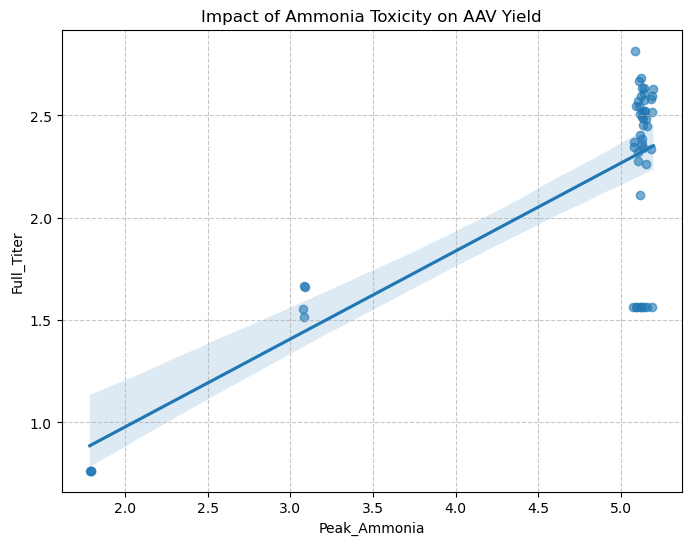

In [8]:
# 1. Join the tables directly in SQL (Much faster than pd.merge)
query = """
SELECT 
    o.Batch_ID, 
    o.Full_Titer, 
    MAX(t.Ammonia) AS Peak_Ammonia
FROM outcomes o
JOIN telemetry_aligned t ON o.Batch_ID = t.Batch_ID
GROUP BY o.Batch_ID, o.Full_Titer
"""

df_corr = con.execute(query).df()

# 2. Visualize the relationship
plt.figure(figsize=(8, 6))
sns.regplot(data=df_corr, x='Peak_Ammonia', y='Full_Titer', scatter_kws={'alpha':0.6})

plt.title('Impact of Ammonia Toxicity on AAV Yield')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Creating a fermentation graph to have an overview of the process

In [9]:
query = """
SELECT 
    t.Hour,
    t.pH,
    t.VCD, 
    t.Glucose, 
    t.Lactate, 
    t.Ammonia, 
    t.Product
FROM telemetry_aligned t 
WHERE t.Batch_ID = 'BATCH_025'
"""

df_culture_graph = con.execute(query).df()

In [10]:
df_culture_graph.tail(5)

,Hour,pH,VCD,Glucose,Lactate,Ammonia,Product
236,236.0,5.730949,20.549210,-1.225627e-17,30.356781,4.924934,7.089820
237,237.0,5.739175,20.537031,-1.013787e-17,30.313789,4.936211,7.132548
238,238.0,5.752227,20.530942,-9.078668e-18,30.079614,4.976389,7.153912
239,239.0,5.770706,20.518763,-6.960265e-18,29.645921,5.038519,7.196640
240,240.0,5.776133,20.506583,-4.841862e-18,29.446404,5.060472,7.239368


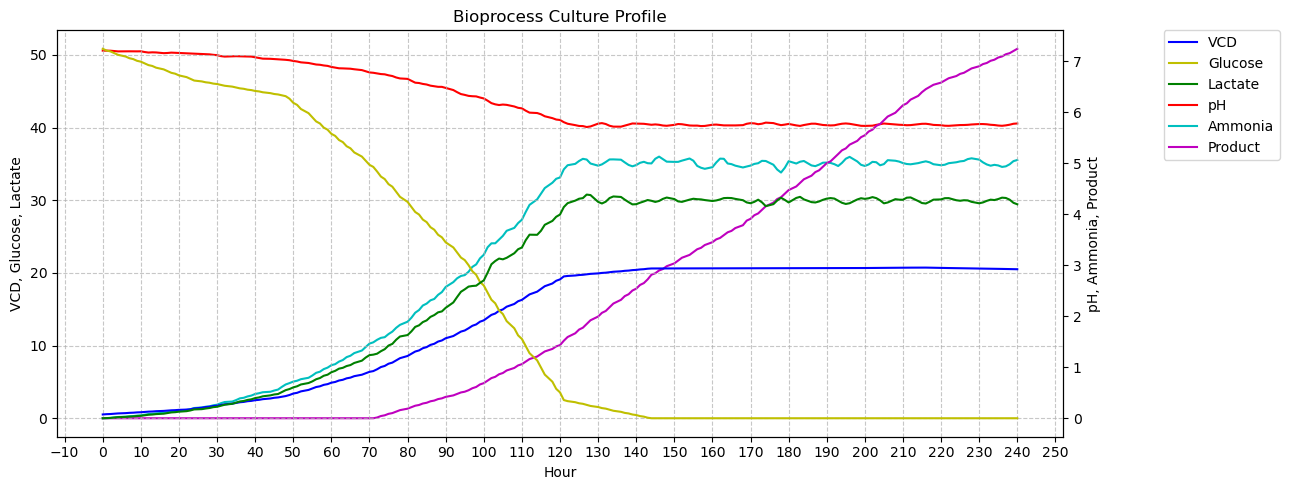

In [11]:
import matplotlib.ticker as ticker

# pH, ammonia and product on secondary axis
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.set_ylabel('VCD, Glucose, Lactate')
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
colors_1 = ("b","y", "g")
df_culture_graph.plot(x='Hour', y = ["VCD", "Glucose", "Lactate"], color=colors_1, ax= ax1)

ax2 = ax1.twinx()
ax2.set_ylabel('pH, Ammonia, Product')
colors_2 = ("r","c","m")
df_culture_graph.plot(x='Hour', y = ["pH", "Ammonia", "Product"], color=colors_2, ax= ax2)

ax1.set_zorder(ax2.get_zorder() + 1) 
# Make ax1's background transparent so we can see ax2 behind it
ax1.patch.set_visible(False) 
# Explicitly turn on the grid for the front layer (ax1)
ax1.grid(True, linestyle='--', alpha=0.7)

# Get legends from both axes and combine them
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Remove the individual legends created by Pandas
ax1.get_legend().remove()
ax2.get_legend().remove()

# Create one single unified legend
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper left', bbox_to_anchor=(1.1, 1), borderaxespad=0.)

plt.title('Bioprocess Culture Profile')
plt.tight_layout()
plt.show()

In [12]:
con.close()